We begin our StreetSwift analysis by imporitngf the necessary tools and by importing the excell dataset.

In [10]:
# Install the ODS engine and import pandas for data manipulation
!pip install odfpy
import pandas as pd

In [11]:
# Load the raw ODS spreadsheet into the dataframe
df = pd.read_excel('StreetSwift.ods', engine='odf')

In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


The StreetSwift dataset is now ready to be manipulated.

---
The next step is a quick clean up.


In [32]:
df = df.drop_duplicates(subset='Trip_ID')

Quick verification. Number of entires.

In [14]:
display(df['Trip_ID'].nunique())

60

In [15]:
# Convert all date strings into a uniform datetime object for trend analysis
df['Date'] = pd.to_datetime(df['Date'])

After converting all dates into a uniform dataframe, we proceed further with the data cleaning process as follow:

Next step - We check for missing values.

In [16]:
# Fill empty billing cells by multiplying usage hours by the $15 hourly rate
df['Total_Bill'] = df['Total_Bill'].fillna(df['Hours_Used'] * 15)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Trip_ID      60 non-null     int64         
 1   User_ID      60 non-null     object        
 2   Car_Type     60 non-null     object        
 3   Date         60 non-null     datetime64[ns]
 4   Hours_Used   60 non-null     float64       
 5   Total_Bill   60 non-null     float64       
 6   City_Zone    60 non-null     object        
 7   User_Rating  60 non-null     int64         
 8   Status       60 non-null     object        
dtypes: datetime64[ns](1), float64(2), int64(2), object(4)
memory usage: 4.3+ KB


Quick "Sanity Check:"


---



The dataset now contains 60 entries (rows) and 9 columns. All columns have 60 non-null values, indicating that there are no missing values after handling Total Bill. The date column is correctly formatted as datetime objects, and other columns have appropriate data types (`int64`, `float64`, `object`).

# **Analysis**:

Now we begin our actual analysis by calculating ratings and total revenue by CityZone.

In [18]:

df.groupby('City_Zone')['Total_Bill'].sum()

,Total_Bill
City_Zone,
Airport,1641.0
Downtown,832.5
Industrial,220.5
Suburbs,804.0


In [19]:

df.groupby('City_Zone')[['Total_Bill', 'User_Rating']].mean()

,Total_Bill,User_Rating
City_Zone,,
Airport,109.400000,3.266667
Downtown,46.250000,4.666667
Industrial,20.045455,1.454545
Suburbs,50.250000,3.750000


Plotting our insights.

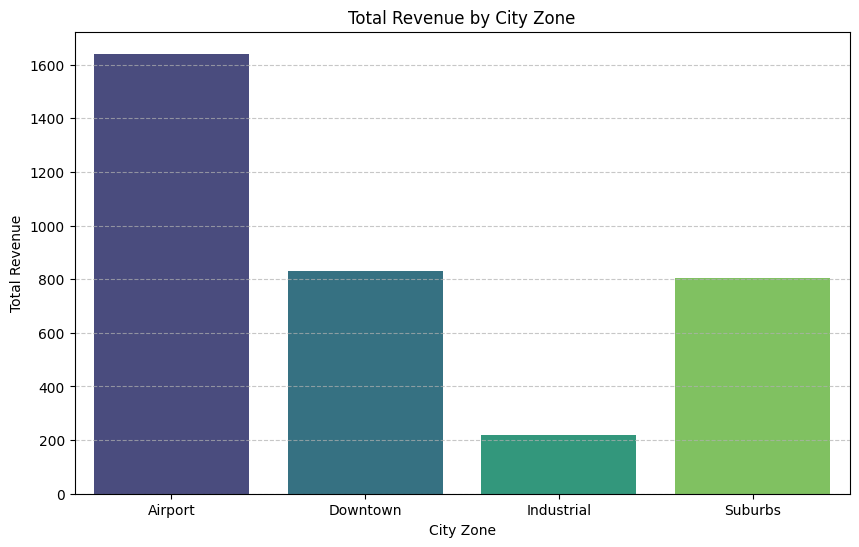

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

total_revenue_by_zone = df.groupby('City_Zone')['Total_Bill'].sum().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='City_Zone', y='Total_Bill', hue='City_Zone', data=total_revenue_by_zone, palette='viridis', legend=False)
plt.title('Total Revenue by City Zone')
plt.xlabel('City Zone')
plt.ylabel('Total Revenue')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Detailed** **Business** **Insights** (**with** **Visualizations**)

#### **The 'Industrial Zone' Leak:**

Industrial Zone Cancellation Rate: 36.36%


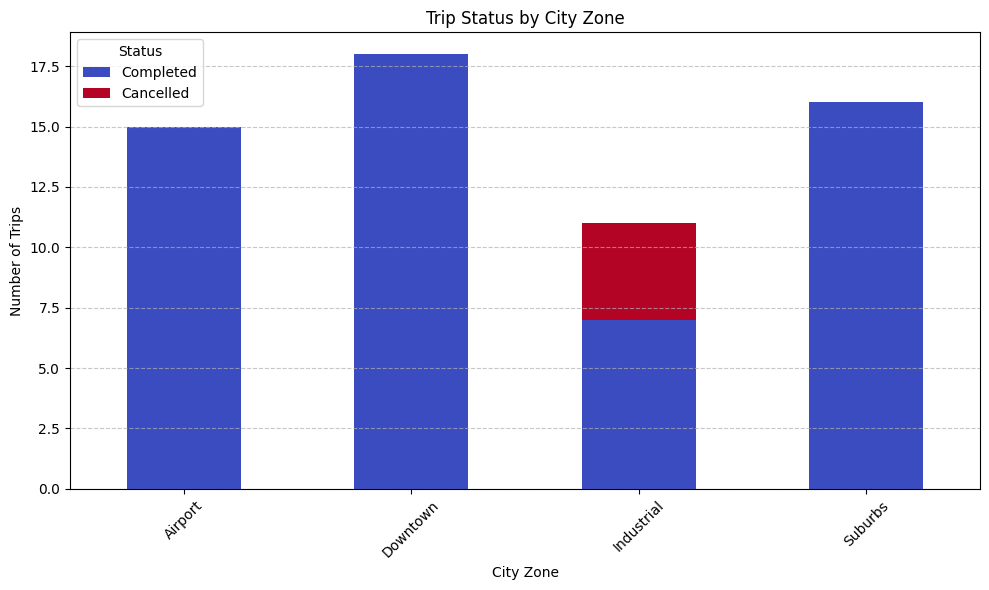

In [21]:
industrial_trips = df[df['City_Zone'] == 'Industrial']
cancelled_industrial_trips = industrial_trips[industrial_trips['Status'] == 'Cancelled']

if not industrial_trips.empty:
    cancellation_rate_industrial = (len(cancelled_industrial_trips) / len(industrial_trips)) * 100
    print(f"Industrial Zone Cancellation Rate: {cancellation_rate_industrial:.2f}%")
else:
    print("No trips found for Industrial Zone.")

cancellation_rates_by_zone = df.groupby('City_Zone')['Status'].apply(lambda x: (x == 'Cancelled').sum() / len(x) * 100).reset_index(name='Cancellation_Rate')

status_counts = df.groupby(['City_Zone', 'Status']).size().unstack(fill_value=0)
status_counts = status_counts.reindex(columns=['Completed', 'Cancelled'], fill_value=0) # Ensure order

status_counts.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='coolwarm')
plt.title('Trip Status by City Zone')
plt.xlabel('City Zone')
plt.ylabel('Number of Trips')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Status')
plt.tight_layout()
plt.show()

This analysis shows that the Industrial zone has a high cancellation rate, indicating potential issues with service reliability or demand in this area. This warrants further investigation to understand why trips are being cancelled.

#### **Asset Underutilization:**

Average trip duration for Economy vehicles: 2.15 hours


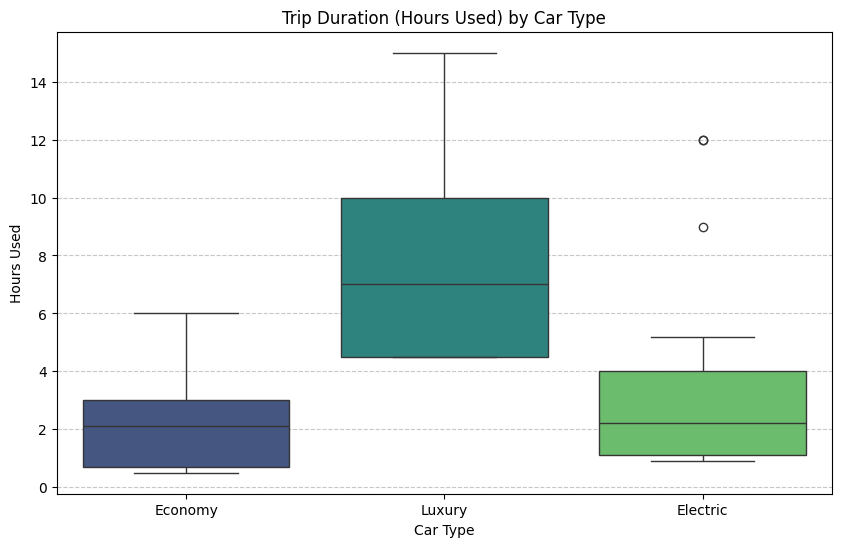

In [22]:
economy_vehicles = df[df['Car_Type'] == 'Economy']
average_hours_economy = economy_vehicles['Hours_Used'].mean()

print(f"Average trip duration for Economy vehicles: {average_hours_economy:.2f} hours")

plt.figure(figsize=(10, 6))
sns.boxplot(x='Car_Type', y='Hours_Used', hue='Car_Type', data=df, palette='viridis', legend=False)
plt.title('Trip Duration (Hours Used) by Car Type')
plt.xlabel('Car Type')
plt.ylabel('Hours Used')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

With an average trip duration of less than an hour for 'Economy' vehicles, the operational costs per trip (maintenance, insurance, etc.) might outweigh the revenue generated. This suggests that the current pricing model for short economy trips might lead to a net loss, highlighting an opportunity to adjust pricing strategies or minimum rental durations.

#### **Luxury Quality Gap:**

Average User Rating for Luxury vehicles: 3.15
Average User Rating for Electric vehicles: 3.68
Luxury vehicles have a 14.34% lower rating compared to Electric vehicles.


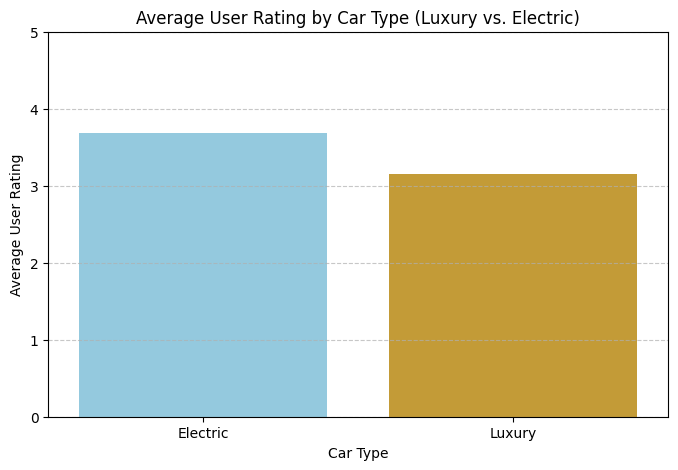

In [23]:
luxury_rating = df[df['Car_Type'] == 'Luxury']['User_Rating'].mean()
electric_rating = df[df['Car_Type'] == 'Electric']['User_Rating'].mean()

print(f"Average User Rating for Luxury vehicles: {luxury_rating:.2f}")
print(f"Average User Rating for Electric vehicles: {electric_rating:.2f}")

if electric_rating > 0:
    rating_difference_percentage = ((electric_rating - luxury_rating) / electric_rating) * 100
    print(f"Luxury vehicles have a {rating_difference_percentage:.2f}% lower rating compared to Electric vehicles.")
else:
    print("Cannot compare ratings as Electric vehicle rating is zero.")

ratings_data = df[df['Car_Type'].isin(['Luxury', 'Electric'])].groupby('Car_Type')['User_Rating'].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(x='Car_Type', y='User_Rating', hue='Car_Type', data=ratings_data, palette={'Luxury': 'goldenrod', 'Electric': 'skyblue'}, legend=False)
plt.title('Average User Rating by Car Type (Luxury vs. Electric)')
plt.xlabel('Car Type')
plt.ylabel('Average User Rating')
plt.ylim(0, 5)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

The significantly lower average user rating for 'Luxury' vehicles compared to 'Electric' ones indicates a potential mismatch between customer expectations and the actual experience. Despite their premium price, 'Luxury' vehicles might be failing to deliver on quality, comfort, or overall user satisfaction, suggesting a need for quality checks or a re-evaluation of the 'Luxury' offering.

### Conclusion

The analysis reveals that the **Airport** zone generates the highest total revenue and has the highest average hours used. Conversely, the **Industrial** zone has the lowest revenue and average hours used, indicating it's the least profitable area for the business. This suggests a need to investigate the challenges or lack of demand in the Industrial zone and potentially focus on strategies to enhance performance there, or reallocate resources to higher-performing zones like the Airport.